# M146 Final Project - Hints / Starter Notebook

This notebook is meant to make the project runnable in Google Colab. Most helper code is provided. Your job is to run the experiments, make a few intuitive choices, and explain what you observe.

The main Part B path is: base model -> LoRA 1k -> LoRA 2k -> 3-shot prompting. The prompt playground at the end is bonus.


In [ ]:

# Colab setup: run this once in a fresh runtime if imports fail.
%pip install -q datasets transformers accelerate sentence-transformers scikit-learn matplotlib peft trl bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 761.1/761.1 kB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 41.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 21.8 MB/s eta 0:00:00


In [ ]:
%pip install -q torchao --upgrade


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 61.6 MB/s eta 0:00:00


In [ ]:

import os
import re
import gc
import json
import math
import time
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
OUTPUT_DIR = Path("m146_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Device:", DEVICE)


def clear_memory(*names):
    """Delete large variables by name and clear Python/CUDA memory."""
    for name in names:
        if name in globals():
            del globals()[name]
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()


Device: cuda


In [ ]:
def clear_memory(*names):
    """Delete large variables by name and clear Python/CUDA memory."""
    for name in names:
        if name in globals():
            del globals()[name]
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()


## Part A: PAWS Sentence-Pair Classification


In [ ]:
paws = load_dataset("google-research-datasets/paws", "labeled_final")
print(paws)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


DatasetDict({
    train: Dataset({
        features: ['id', 'sentence1', 'sentence2', 'label'],
        num_rows: 49401
    })
    test: Dataset({
        features: ['id', 'sentence1', 'sentence2', 'label'],
        num_rows: 8000
    })
    validation: Dataset({
        features: ['id', 'sentence1', 'sentence2', 'label'],
        num_rows: 8000
    })
})


### A.1 Data Inspection and Lexical Overlap

Report split sizes and label balance, compute a lexical overlap score (e.g., Jaccard) for the test split, and plot overlap histograms by label. Write the supporting code yourself.

In [ ]:
for split_name in ["train", "validation", "test"]:
    split = paws[split_name]
    labels = split["label"]
    total = len(labels)
    n_para = sum(labels)
    n_not = total - n_para
    print(f"{split_name}: {total} examples | label 1 (paraphrase): {n_para} ({100*n_para/total:.1f}%) | label 0 (not paraphrase): {n_not} ({100*n_not/total:.1f}%)")

train: 49401 examples | label 1 (paraphrase): 21829 (44.2%) | label 0 (not paraphrase): 27572 (55.8%)
validation: 8000 examples | label 1 (paraphrase): 3539 (44.2%) | label 0 (not paraphrase): 4461 (55.8%)
test: 8000 examples | label 1 (paraphrase): 3536 (44.2%) | label 0 (not paraphrase): 4464 (55.8%)


In [ ]:
def jaccard(s1, s2):
    a = set(s1.lower().split())
    b = set(s2.lower().split())
    return len(a & b) / len(a | b)

test_split = paws["test"]

high_overlap_0 = [(ex, jaccard(ex["sentence1"], ex["sentence2"]))
                   for ex in test_split if ex["label"] == 0]
high_overlap_1 = [(ex, jaccard(ex["sentence1"], ex["sentence2"]))
                   for ex in test_split if ex["label"] == 1]

high_overlap_0.sort(key=lambda x: -x[1])
high_overlap_1.sort(key=lambda x: -x[1])

print("=== TOP 5 HIGH-OVERLAP label=0 (NOT paraphrase) ===")
for ex, score in high_overlap_0[:5]:
    print(f"Jaccard: {score:.3f}")
    print(f"  S1: {ex['sentence1']}")
    print(f"  S2: {ex['sentence2']}\n")

print("=== TOP 5 HIGH-OVERLAP label=1 (paraphrase) ===")
for ex, score in high_overlap_1[:5]:
    print(f"Jaccard: {score:.3f}")
    print(f"  S1: {ex['sentence1']}")
    print(f"  S2: {ex['sentence2']}\n")

=== TOP 5 HIGH-OVERLAP label=0 (NOT paraphrase) ===
Jaccard: 1.000
  S1: A unique feature of the human metate is the lack of ceremonial figures .
  S2: A unique feature of ceremonial metate is the lack of human figures .

Jaccard: 1.000
  S1: Doyline is an entry point to Lake Bistineau and the Bistineau State Park .
  S2: Lake Bistineau is an entry point to Doyline and the Lake Bistineau State Park .

Jaccard: 1.000
  S1: Companies based in the larger rivium include Rockwell Automation , Royal Dutch Shell , Sodexho Nederland , Pfizer , Van Oord and many more .
  S2: Companies based in the larger Rivium include Rockwell Automation , Pfizer Nederland , Sodexho Nederland , Royal Dutch Shell , Van Oord , and many more .

Jaccard: 1.000
  S1: In June of 1997 , Kristin met Richard Armstrong .
  S2: In June of 1997 , Armstrong met Kristin Richard .

Jaccard: 1.000
  S1: Most Jewish anarchists supported anarchosyndicalism and communist anarchism , while a few were individualist anarchists .
  

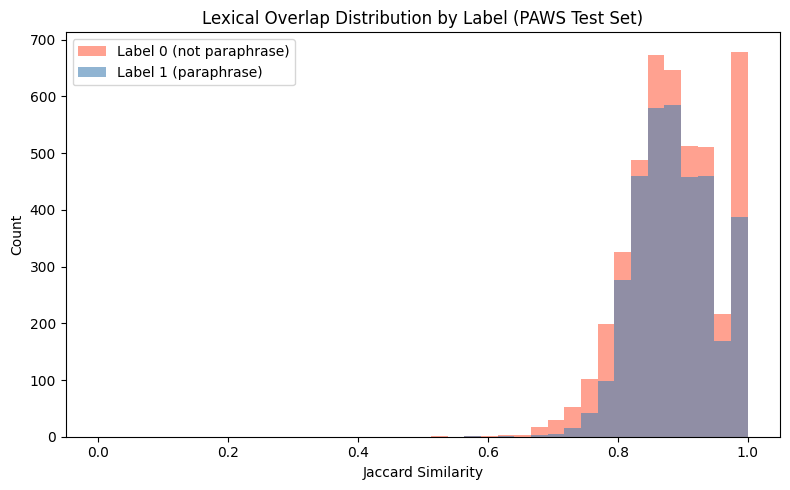

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

test_split = paws["test"]

scores_0 = [jaccard(ex["sentence1"], ex["sentence2"]) for ex in test_split if ex["label"] == 0]
scores_1 = [jaccard(ex["sentence1"], ex["sentence2"]) for ex in test_split if ex["label"] == 1]

plt.figure(figsize=(8, 5))
bins = np.linspace(0, 1, 40)
plt.hist(scores_0, bins=bins, alpha=0.6, label="Label 0 (not paraphrase)", color="tomato")
plt.hist(scores_1, bins=bins, alpha=0.6, label="Label 1 (paraphrase)", color="steelblue")
plt.xlabel("Jaccard Similarity")
plt.ylabel("Count")
plt.title("Lexical Overlap Distribution by Label (PAWS Test Set)")
plt.legend()
plt.tight_layout()
plt.savefig("m146_outputs/jaccard_histogram.png", dpi=150)
plt.show()

Before training A.2 models, write your hypothesis: which should work better on PAWS, bi-encoder or cross-encoder, and why?


### A.2 Encoder Models

Run the cells and report accuracy, F1, confusion matrices, disagreements, and the accuracy-efficiency tradeoff.


In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import numpy as np
import time

BI_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
bi_encoder = SentenceTransformer(BI_MODEL, device=str(DEVICE))

def encode_sentences(texts, batch_size=128):
    return bi_encoder.encode(
        list(texts),
        batch_size=batch_size,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True,
    )

print("Encoding train...")
train_u = encode_sentences(paws["train"]["sentence1"])
train_v = encode_sentences(paws["train"]["sentence2"])

print("Encoding validation...")
val_u = encode_sentences(paws["validation"]["sentence1"])
val_v = encode_sentences(paws["validation"]["sentence2"])

print("Encoding test...")
test_u = encode_sentences(paws["test"]["sentence1"])
test_v = encode_sentences(paws["test"]["sentence2"])

# Build pair features: [u, v, |u-v|, u*v]
def build_features(u, v):
    return np.concatenate([u, v, np.abs(u - v), u * v], axis=1)

X_train = build_features(train_u, train_v)
X_val   = build_features(val_u, val_v)
X_test  = build_features(test_u, test_v)

y_train = np.array(paws["train"]["label"])
y_val   = np.array(paws["validation"]["label"])
y_test  = np.array(paws["test"]["label"])

best_C, best_val_acc = None, 0
for C in [0.01, 0.1, 1.0, 10.0]:
    clf = LogisticRegression(C=C, max_iter=1000)
    clf.fit(X_train, y_train)
    val_acc = accuracy_score(y_val, clf.predict(X_val))
    print(f"C={C}: val accuracy={val_acc:.4f}")
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_C = C

print(f"\nBest C: {best_C}")

clf = LogisticRegression(C=best_C, max_iter=1000)
clf.fit(X_train, y_train)

# Evaluate on test
start = time.time()
test_preds = clf.predict(X_test)
inference_time = time.time() - start

test_acc = accuracy_score(y_test, test_preds)
test_f1  = f1_score(y_test, test_preds)
test_cm  = confusion_matrix(y_test, test_preds)

print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test F1:       {test_f1:.4f}")
print(f"Confusion Matrix:\n{test_cm}")
print(f"Inference time for {len(X_test)} pairs: {inference_time:.3f}s")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Encoding test...


Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

C=0.01: val accuracy=0.5984
C=0.1: val accuracy=0.6071
C=1.0: val accuracy=0.6226
C=10.0: val accuracy=0.6212

Best C: 1.0

Test Accuracy: 0.6181
Test F1:       0.5267
Confusion Matrix:
[[3245 1219]
 [1836 1700]]
Inference time for 8000 pairs: 0.127s


Use the bi-encoder helper functions above to build sentence-pair features, train a simple classifier, and report validation/test metrics. Do not forget the confusion matrix.

In [ ]:

from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer

CROSS_MODEL = "distilbert-base-uncased"
MAX_LEN = 128
cross_tokenizer = AutoTokenizer.from_pretrained(CROSS_MODEL)


def tokenize_pairs(batch):
    return cross_tokenizer(
        batch["sentence1"],
        batch["sentence2"],
        truncation=True,
        max_length=MAX_LEN,
        padding="max_length",
    )


def binary_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, preds), "f1": f1_score(labels, preds)}


def training_args(output_dir, learning_rate):
    kwargs = dict(
        output_dir=output_dir,
        learning_rate=learning_rate,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=64,
        num_train_epochs=1,
        save_strategy="no",
        report_to="none",
        fp16=torch.cuda.is_available(),
        logging_steps=100,
    )
    try:
        return TrainingArguments(eval_strategy="epoch", **kwargs)
    except TypeError:
        return TrainingArguments(evaluation_strategy="epoch", **kwargs)


def train_cross_encoder(tokenized_ds, lr=2e-5):
    model = AutoModelForSequenceClassification.from_pretrained(CROSS_MODEL, num_labels=2)
    args = training_args(f"m146_outputs/cross_encoder_lr_{lr}", lr)
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=tokenized_ds["train"],
        eval_dataset=tokenized_ds["validation"],
        processing_class=cross_tokenizer,
        compute_metrics=binary_metrics,
    )
    trainer.train()
    return trainer, trainer.evaluate()


In [ ]:
import time

tokenized_ds = paws.map(tokenize_pairs, batched=True)
tokenized_ds = tokenized_ds.rename_column("label", "labels")
tokenized_ds.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

best_lr, best_val_acc, best_trainer = None, 0, None

for lr in [5e-5, 2e-5]:
    print(f"\nTraining with lr={lr}")
    trainer, val_results = train_cross_encoder(tokenized_ds, lr=lr)
    print(f"lr={lr} val accuracy: {val_results['eval_accuracy']:.4f}")
    if val_results["eval_accuracy"] > best_val_acc:
        best_val_acc = val_results["eval_accuracy"]
        best_lr = lr
        best_trainer = trainer

print(f"\nBest lr: {best_lr}")

# Evaluate on test
start = time.time()
test_results = best_trainer.predict(tokenized_ds["test"])
inference_time = time.time() - start

test_preds = np.argmax(test_results.predictions, axis=-1)
test_labels = np.array(paws["test"]["label"])

test_acc = accuracy_score(test_labels, test_preds)
test_f1  = f1_score(test_labels, test_preds)
test_cm  = confusion_matrix(test_labels, test_preds)

cross_preds = test_preds

print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test F1:       {test_f1:.4f}")
print(f"Confusion Matrix:\n{test_cm}")
print(f"Inference time for 8000 pairs: {inference_time:.3f}s")


Training with lr=5e-05


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.424414,0.445462,0.798000,0.791322


Training Loss,Validation Loss,Epoch,Accuracy,F1
0.424414,0.445462,1,0.798000,0.791322


...

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.396449,0.400081,0.822375,0.810255


Training Loss,Validation Loss,Epoch,Accuracy,F1
0.396449,0.400081,1,0.822375,0.810255


lr=2e-05 val accuracy: 0.8224

Best lr: 2e-05



Test Accuracy: 0.8190
Test F1:       0.8038
Confusion Matrix:
[[3585  879]
 [ 569 2967]]
Inference time for 8000 pairs: 8.074s


In [ ]:
bi_preds = clf.predict(X_test)
test_labels = np.array(paws["test"]["label"])

disagreements = np.where(bi_preds != cross_preds)[0]
print(f"Total disagreements: {len(disagreements)} out of {len(test_labels)}")

bi_correct = np.sum(bi_preds[disagreements] == test_labels[disagreements])
cross_correct = np.sum(cross_preds[disagreements] == test_labels[disagreements])
print(f"Bi-encoder correct on disagreements: {bi_correct}")
print(f"Cross-encoder correct on disagreements: {cross_correct}")

print("\n=== 5 Disagreement Examples ===")
for i, idx in enumerate(disagreements[:5]):
    ex = paws["test"][int(idx)]
    print(f"\nExample {i+1} (index {idx}):")
    print(f"  S1: {ex['sentence1']}")
    print(f"  S2: {ex['sentence2']}")
    print(f"  True label:    {ex['label']}")
    print(f"  Bi-encoder:    {bi_preds[idx]}")
    print(f"  Cross-encoder: {cross_preds[idx]}")
    print(f"  Bi correct: {bi_preds[idx] == ex['label']} | Cross correct: {cross_preds[idx] == ex['label']}")

Total disagreements: 3129 out of 8000
Bi-encoder correct on disagreements: 761
Cross-encoder correct on disagreements: 2368

=== 5 Disagreement Examples ===

Example 1 (index 4):
  S1: Luciano Williames Dias ( born July 25 , 1970 ) is a Brazilian football coach and former player .
  S2: Luciano Williames Dias ( born 25 July 1970 ) is a former football coach and Brazilian player .
  True label:    0
  Bi-encoder:    1
  Cross-encoder: 0
  Bi correct: False | Cross correct: True

Example 2 (index 6):
  S1: The smallest number that can be represented in two positive and seventh ways as a sum of four different powers is 2056364173794800 .
  S2: The smallest number that can be represented as a sum of four positive seventh potences in two different ways is 2056364173794800 .
  True label:    0
  Bi-encoder:    0
  Cross-encoder: 1
  Bi correct: True | Cross correct: False

Example 3 (index 7):
  S1: His father emigrated to Missouri in 1868 , but returned when his wife became ill and before t

Use the cross-encoder helper functions above to tokenize PAWS sentence pairs and fine-tune a small classifier. Try the learning rates suggested in the PDF if compute allows.

After both encoder models are evaluated, inspect test examples where their predictions disagree and describe the patterns you see.

> **Memory tip:** Before loading the instruction model for A.3, free GPU memory by running `clear_memory("bi_encoder", "trainer")` (or whatever names you used).

### A.3 Prompt-Based PAWS Classification

This cell gives model-loading and evaluation utilities. Write the actual PAWS prompt yourself in `PAWS_PROMPT_TEMPLATE`. Keep the output labels parseable as `paraphrase` and `not_paraphrase`.


In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM

INSTRUCT_MODEL = "Qwen/Qwen2.5-1.5B-Instruct"

# Write your PAWS classification prompt here.
# IMPORTANT: Use {sentence1} and {sentence2} where the two sentences should be inserted in the prompt.
PAWS_PROMPT_TEMPLATE = """
""".strip()


def load_instruct_model(model_name=INSTRUCT_MODEL):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    tokenizer.padding_side = "left"
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    dtype = torch.float16 if torch.cuda.is_available() else torch.float32
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=dtype,
        device_map="auto",
    )
    model.eval()
    return model, tokenizer


def chat_text(tokenizer, messages):
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)


def make_paws_prompt(sentence1, sentence2, prompt_template=PAWS_PROMPT_TEMPLATE):
    return prompt_template.format(sentence1=sentence1, sentence2=sentence2)


def parse_paws_output(text):
    cleaned = text.strip().lower().replace("-", "_").replace(" ", "_")
    if "not_paraphrase" in cleaned:
        return 0
    if re.search(r"\bparaphrase\b", cleaned):
        return 1
    return -1


def balanced_subset(split, n_per_class=100, seed=SEED):
    rng = np.random.default_rng(seed)
    labels = np.array(split["label"])
    indices = []
    for label in [0, 1]:
        candidates = np.flatnonzero(labels == label)
        indices.extend(rng.choice(candidates, size=n_per_class, replace=False).tolist())
    rng.shuffle(indices)
    return split.select(indices), indices


def generate_texts(model, tokenizer, prompts, max_new_tokens=8, batch_size=8):
    outputs = []
    for start in range(0, len(prompts), batch_size):
        batch = prompts[start:start + batch_size]
        inputs = tokenizer(batch, return_tensors="pt", padding=True, truncation=True).to(model.device)
        prompt_len = inputs["input_ids"].shape[1]
        with torch.no_grad():
            generated = model.generate(**inputs, do_sample=False, max_new_tokens=max_new_tokens)
        for i in range(len(batch)):
            outputs.append(tokenizer.decode(generated[i][prompt_len:], skip_special_tokens=True).strip())
    return outputs


def evaluate_prompted_paws(model, tokenizer, split, prompt_template=PAWS_PROMPT_TEMPLATE, few_shot_examples=None, batch_size=8):
    prompts = []
    for ex in split:
        messages = []
        if few_shot_examples:
            for fs in few_shot_examples:
                messages.append({"role": "user", "content": make_paws_prompt(fs["sentence1"], fs["sentence2"], prompt_template)})
                messages.append({"role": "assistant", "content": "paraphrase" if fs["label"] == 1 else "not_paraphrase"})
        messages.append({"role": "user", "content": make_paws_prompt(ex["sentence1"], ex["sentence2"], prompt_template)})
        prompts.append(chat_text(tokenizer, messages))
    raw = generate_texts(model, tokenizer, prompts, batch_size=batch_size)
    pred = np.array([parse_paws_output(x) for x in raw])
    y = np.array(split["label"])
    valid = pred != -1
    return {
        "accuracy_invalid_wrong": float((pred == y).mean()),
        "coverage": float(valid.mean()),
        "accuracy_valid_only": accuracy_score(y[valid], pred[valid]) if valid.any() else np.nan,
        "confusion_matrix": confusion_matrix(y[valid], pred[valid], labels=[0, 1]) if valid.any() else None,
        "pred": pred,
        "raw": raw,
    }


In [ ]:
clear_memory("bi_encoder", "best_trainer", "model")

instruct_model, instruct_tokenizer = load_instruct_model(INSTRUCT_MODEL)
print("Model loaded!")

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Model loaded!


In [ ]:
PAWS_PROMPT_TEMPLATE = """
Determine whether the following two sentences are paraphrases of each other.
A paraphrase expresses the same meaning even if worded differently.

Sentence 1: {sentence1}
Sentence 2: {sentence2}

Answer with exactly one word: paraphrase or not_paraphrase.
""".strip()

paws_subset, subset_indices = balanced_subset(paws["test"], n_per_class=100)
print(f"Subset size: {len(paws_subset)}")
print(f"Label distribution: {Counter(paws_subset['label'])}")

Subset size: 200
Label distribution: Counter({1: 100, 0: 100})


In [ ]:
zero_shot_results = evaluate_prompted_paws(
    instruct_model, instruct_tokenizer, paws_subset,
    prompt_template=PAWS_PROMPT_TEMPLATE
)

print(f"Coverage:              {zero_shot_results['coverage']:.3f}")
print(f"Accuracy (all):        {zero_shot_results['accuracy_invalid_wrong']:.3f}")
print(f"Accuracy (valid only): {zero_shot_results['accuracy_valid_only']:.3f}")
print(f"Confusion Matrix:\n{zero_shot_results['confusion_matrix']}")

Coverage:              1.000
Accuracy (all):        0.745
Accuracy (valid only): 0.745
Confusion Matrix:
[[60 40]
 [11 89]]


In [ ]:
few_shot_examples = []
train_labels = np.array(paws["train"]["label"])

# 2 label 0 examples
label0_indices = np.where(train_labels == 0)[0][:2]
# 2 label 1 examples
label1_indices = np.where(train_labels == 1)[0][:2]

for idx in list(label0_indices) + list(label1_indices):
    few_shot_examples.append(paws["train"][int(idx)])

print(f"Few-shot examples: {len(few_shot_examples)}")
for ex in few_shot_examples:
    print(f"  label={ex['label']}: {ex['sentence1'][:60]}...")

# Run few-shot evaluation
few_shot_results = evaluate_prompted_paws(
    instruct_model, instruct_tokenizer, paws_subset,
    prompt_template=PAWS_PROMPT_TEMPLATE,
    few_shot_examples=few_shot_examples
)

print(f"\nCoverage:              {few_shot_results['coverage']:.3f}")
print(f"Accuracy (all):        {few_shot_results['accuracy_invalid_wrong']:.3f}")
print(f"Accuracy (valid only): {few_shot_results['accuracy_valid_only']:.3f}")
print(f"Confusion Matrix:\n{few_shot_results['confusion_matrix']}")

Few-shot examples: 4
  label=0: In Paris , in October 1560 , he secretly met the English amb...
  label=0: There are also specific discussions , public profile debates...
  label=1: The NBA season of 1975 -- 76 was the 30th season of the Nati...
  label=1: When comparable rates of flow can be maintained , the result...

Coverage:              1.000
Accuracy (all):        0.815
Accuracy (valid only): 0.815
Confusion Matrix:
[[79 21]
 [16 84]]


In [ ]:
PAWS_PROMPT_ALT = """
Do these two sentences mean the same thing?

Sentence 1: {sentence1}
Sentence 2: {sentence2}

Reply with only: paraphrase or not_paraphrase.
""".strip()

alt_results = evaluate_prompted_paws(
    instruct_model, instruct_tokenizer, paws_subset,
    prompt_template=PAWS_PROMPT_ALT
)

print(f"Coverage:              {alt_results['coverage']:.3f}")
print(f"Accuracy (all):        {alt_results['accuracy_invalid_wrong']:.3f}")
print(f"Accuracy (valid only): {alt_results['accuracy_valid_only']:.3f}")
print(f"Confusion Matrix:\n{alt_results['confusion_matrix']}")

Coverage:              1.000
Accuracy (all):        0.500
Accuracy (valid only): 0.500
Confusion Matrix:
[[100   0]
 [100   0]]


For A.3, load the instruction model, create the fixed balanced PAWS test subset, write your own prompt, and evaluate the prompted classifier.

For the few-shot PAWS prompt, choose 4-6 labeled examples from the training split only. Then compare zero-shot, few-shot, and one alternate prompt wording.

> **Memory tip:** Before loading the GSM8K math model, free GPU memory by running `clear_memory("instruct_model", "instruct_tokenizer")` (or whatever names you used).

## Part B: GSM8K Reasoning

The prompt below is intentionally minimal. You can add your own instructions above the final-answer rule.


In [ ]:
# You may add creative instructions above the final-answer rule.
# If you do nothing, this minimal prompt still runs.
# Keep the final line parseable, or the evaluator may mark correct reasoning as wrong.
# Do not remove the boxed answer rule. Please edit the first line of the prompt and add your instructions (however long you want).
SYSTEM_PROMPT = """
Your task is to solve the math problem.

Final answer rule:
The last line of your response must be exactly:
\\boxed{ANSWER}
""".strip()

gsm8k = load_dataset("openai/gsm8k", "main")
gsm8k_test_100 = gsm8k["test"].select(range(100))
print(f"Test split size: {len(gsm8k['test'])}")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/7.93k [00:00<?, ?B/s]

main/train-00000-of-00001.parquet:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

main/test-00000-of-00001.parquet:   0%|          | 0.00/419k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

Test split size: 1319


In [ ]:
clear_memory("instruct_model", "instruct_tokenizer")

In [ ]:

from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import LoraConfig, get_peft_model, PeftModel, TaskType
from trl import SFTTrainer, SFTConfig

MATH_MODEL = "Qwen/Qwen2.5-1.5B-Instruct"
N_EVAL = 100

gsm8k = load_dataset("openai/gsm8k", "main")
gsm8k_test_100 = gsm8k["test"].select(range(N_EVAL))

def extract_boxed(text):
    idx = text.rfind("\\boxed{")
    if idx == -1:
        return None
    start = idx + len("\\boxed{")
    depth = 1
    pos = start
    while pos < len(text) and depth > 0:
        if text[pos] == "{":
            depth += 1
        elif text[pos] == "}":
            depth -= 1
        pos += 1
    if depth != 0:
        return None
    return text[start:pos - 1]


def extract_gt(raw_answer):
    match = re.search(r"####\s*(.+)", raw_answer)
    return match.group(1).strip().replace(",", "") if match else raw_answer.strip()


def extract_model_answer(text):
    boxed = extract_boxed(text)
    if boxed is not None:
        return boxed.strip()
    nums = re.findall(r"-?\d+(?:\.\d+)?", text)
    return nums[-1] if nums else ""


def normalize_answer(ans):
    s = str(ans).strip().replace(",", "").replace("$", "").replace("%", "").replace(" ", "")
    s = re.sub(r"\\text\{([^}]*)\}", r"\1", s)
    s = re.sub(r"\\(left|right|displaystyle)", "", s)
    s = re.sub(r"\\d?frac\{([^}]+)\}\{([^}]+)\}", r"\1/\2", s)
    try:
        v = float(s)
        if math.isfinite(v):
            return str(int(v)) if v == int(v) else str(v)
    except (ValueError, OverflowError):
        pass
    if "/" in s and s.count("/") == 1:
        try:
            a, b = s.split("/")
            return f"{float(a) / float(b):.10g}"
        except (ValueError, ZeroDivisionError):
            pass
    return s


def answers_match(pred, gt):
    p, g = normalize_answer(pred), normalize_answer(gt)
    if p == g:
        return True
    try:
        return abs(float(p) - float(g)) < 1e-6
    except (ValueError, TypeError):
        return False


def load_math_model(model_name=MATH_MODEL, lora_path=None):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    tokenizer.padding_side = "left"
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    dtype = torch.bfloat16 if torch.cuda.is_available() else torch.float32
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=dtype,
        device_map="auto",
        attn_implementation="eager",
    )
    if lora_path:
        model = PeftModel.from_pretrained(model, lora_path)
    model.eval()
    return model, tokenizer


def make_gsm_prompts(tokenizer, questions, system_prompt=SYSTEM_PROMPT, few_shot_messages=None):
    prompts = []
    for q in questions:
        messages = [{"role": "system", "content": system_prompt}]
        if few_shot_messages:
            messages.extend(few_shot_messages)
        messages.append({"role": "user", "content": q})
        prompts.append(tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True))
    return prompts


def generate_math(model, tokenizer, questions, system_prompt=SYSTEM_PROMPT, few_shot_messages=None, batch_size=16, max_new_tokens=512):
    responses = []
    for start in range(0, len(questions), batch_size):
        batch_questions = questions[start:start + batch_size]
        prompts = make_gsm_prompts(tokenizer, batch_questions, system_prompt=system_prompt, few_shot_messages=few_shot_messages)
        inputs = tokenizer(prompts, return_tensors="pt", padding=True, truncation=True).to(model.device)
        prompt_len = inputs["input_ids"].shape[1]
        with torch.no_grad():
            out = model.generate(**inputs, do_sample=False, max_new_tokens=max_new_tokens)
        for i in range(len(batch_questions)):
            responses.append(tokenizer.decode(out[i][prompt_len:], skip_special_tokens=True).strip())
    return responses


def evaluate_gsm8k(model, tokenizer, split, num_samples=100, system_prompt=SYSTEM_PROMPT, few_shot_messages=None, batch_size=16, output_name=None):
    n = min(num_samples, len(split))
    records = []
    correct = 0
    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        questions = [split[i]["question"] for i in range(start, end)]
        gts = [extract_gt(split[i]["answer"]) for i in range(start, end)]
        responses = generate_math(model, tokenizer, questions, system_prompt=system_prompt, few_shot_messages=few_shot_messages, batch_size=batch_size)
        for offset, (q, gt, resp) in enumerate(zip(questions, gts, responses)):
            pred = extract_model_answer(resp)
            ok = answers_match(pred, gt)
            correct += int(ok)
            records.append({
                "index": start + offset,
                "question": q,
                "ground_truth": gt,
                "model_response": resp,
                "extracted_answer": pred,
                "correct": ok,
            })
    result = {"accuracy": correct / n, "correct": correct, "total": n, "records": records}
    if output_name:
        path = OUTPUT_DIR / output_name
        path.write_text(json.dumps(result, indent=2))
    return result


### B.1-B.2 Base Model Evaluation


*For* B.1, load the base Qwen2.5-1.5B-Instruct model and evaluate it on the fixed 100 GSM8K test questions.

In [ ]:
math_model, math_tokenizer = load_math_model()
print("Model loaded!")

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Model loaded!


In [ ]:
base_results = evaluate_gsm8k(
    math_model, math_tokenizer,
    gsm8k_test_100,
    num_samples=100,
    batch_size=16,
    output_name="base_model_results.json"
)
print(f"Base model accuracy: {base_results['accuracy']:.3f} ({base_results['correct']}/100)")

Base model accuracy: 0.360 (36/100)


In [ ]:
failures = [r for r in base_results["records"] if not r["correct"]]
print(f"Total failures: {len(failures)}")

for i, r in enumerate(failures[:3]):
    print(f"\n{'='*60}")
    print(f"FAILURE {i+1}")
    print(f"Question: {r['question']}")
    print(f"\nModel response:\n{r['model_response']}")
    print(f"\nExtracted answer: {r['extracted_answer']}")
    print(f"Ground truth:     {r['ground_truth']}")

Total failures: 64

FAILURE 1
Question: Josh decides to try flipping a house.  He buys a house for $80,000 and then puts in $50,000 in repairs.  This increased the value of the house by 150%.  How much profit did he make?

Model response:
To determine Josh's profit from flipping the house, we need to follow these steps:

1. Calculate the total cost of buying and repairing the house.
2. Determine the new value of the house after the repairs.
3. Find out how much more money the house is worth than what it originally cost.
4. Subtract the original cost from this amount to find the profit.

Let's go through each step in detail:

### Step 1: Total Cost Calculation
- Initial purchase price of the house: $80,000
- Amount spent on repairs: $50,000

Total cost = Purchase price + Repair costs
\[ \text{Total cost} = \$80,000 + \$50,000 = \$130,000 \]

### Step 2: New Value After Repairs
The problem states that the repairs increased the value of the house by 150%.

New value = Original value + (Or

### B.3-B.7 LoRA Fine-Tuning

The training utilities are provided below. Run the 1k and 2k experiments yourself and record the results in your report.


In [ ]:

LORA_DEFAULTS = {
    "rank": 8,
    "lora_alpha": 16,
    "lora_dropout": 0.05,
    "target_modules": ["q_proj", "k_proj", "v_proj", "o_proj"],
    "learning_rate": 2e-4,
    "epochs": 1,
    "batch_size": 8,
    "grad_accum": 4,
    "max_seq_len": 1024,
}


def build_lora_config():
    return LoraConfig(
        task_type=TaskType.CAUSAL_LM,
        r=LORA_DEFAULTS["rank"],
        lora_alpha=LORA_DEFAULTS["lora_alpha"],
        lora_dropout=LORA_DEFAULTS["lora_dropout"],
        target_modules=LORA_DEFAULTS["target_modules"],
        bias="none",
    )


def format_gsm8k_train_example(example):
    reasoning = example["answer"].split("####")[0].strip()
    final = extract_gt(example["answer"])
    assistant = f"{reasoning}\n\n\\boxed{{{final}}}"
    return {
        "messages": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": example["question"]},
            {"role": "assistant", "content": assistant},
        ]
    }


def train_lora_sft(num_samples, output_dir, model_name=MATH_MODEL):
    output_dir = Path(output_dir)
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    tokenizer.padding_side = "right"
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    dtype = torch.bfloat16 if torch.cuda.is_available() else torch.float32
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=dtype,
        device_map="auto",
        attn_implementation="eager",
    )
    model = get_peft_model(model, build_lora_config())
    model.print_trainable_parameters()

    train_data = gsm8k["train"].select(range(min(num_samples, len(gsm8k["train"]))))
    train_data = train_data.map(format_gsm8k_train_example, remove_columns=train_data.column_names)

    args = SFTConfig(
        output_dir=str(output_dir),
        num_train_epochs=LORA_DEFAULTS["epochs"],
        per_device_train_batch_size=LORA_DEFAULTS["batch_size"],
        gradient_accumulation_steps=LORA_DEFAULTS["grad_accum"],
        learning_rate=LORA_DEFAULTS["learning_rate"],
        lr_scheduler_type="cosine",
        warmup_ratio=0.05,
        bf16=torch.cuda.is_available(),
        logging_steps=10,
        save_strategy="epoch",
        save_total_limit=1,
        report_to="none",
        max_length=LORA_DEFAULTS["max_seq_len"],
        completion_only_loss=True,
    )
    trainer = SFTTrainer(model=model, args=args, train_dataset=train_data, processing_class=tokenizer)
    trainer.train()

    adapter_path = output_dir / "final_adapter"
    model.save_pretrained(adapter_path)
    tokenizer.save_pretrained(adapter_path)
    return str(adapter_path)


In [ ]:
from peft import LoraConfig, get_peft_model, TaskType
from transformers import AutoModelForCausalLM
import torch

model = AutoModelForCausalLM.from_pretrained(
    MATH_MODEL,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    attn_implementation="eager",
)

lora_config = build_lora_config()
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()
clear_memory("model")

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

trainable params: 2,179,072 || all params: 1,545,893,376 || trainable%: 0.1410


> **Memory tip:** Before LoRA training (and between LoRA runs), free GPU memory by running `clear_memory("math_model", "math_tokenizer")` so the base model isn't still resident.

In [ ]:
clear_memory("model", "math_model", "math_tokenizer")
import gc
gc.collect()
torch.cuda.empty_cache()

In [ ]:
import gc
gc.collect()
torch.cuda.empty_cache()
print("GPU memory cleared")
print(f"Free GPU memory: {torch.cuda.mem_get_info()[0]/1e9:.2f} GB")

GPU memory cleared
Free GPU memory: 9.00 GB


In [ ]:
import os
import gc
gc.collect()
torch.cuda.empty_cache()
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

LORA_DEFAULTS["batch_size"] = 4
LORA_DEFAULTS["grad_accum"] = 8
LORA_DEFAULTS["max_seq_len"] = 512

lora_1k_path = train_lora_sft(num_samples=1000, output_dir="m146_outputs/lora_1k")
print(f"Adapter saved to: {lora_1k_path}")

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


trainable params: 2,179,072 || all params: 1,545,893,376 || trainable%: 0.1410


[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss
10,1.307898
20,0.783707
30,0.527473


Adapter saved to: m146_outputs/lora_1k/final_adapter


In [ ]:
clear_memory("math_model", "math_tokenizer")

math_model, math_tokenizer = load_math_model(lora_path="m146_outputs/lora_1k/final_adapter")

lora_1k_results = evaluate_gsm8k(
    math_model, math_tokenizer,
    gsm8k_test_100,
    num_samples=100,
    batch_size=16,
    output_name="lora_1k_results.json"
)
print(f"LoRA 1k accuracy: {lora_1k_results['accuracy']:.3f} ({lora_1k_results['correct']}/100)")

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

LoRA 1k accuracy: 0.470 (47/100)


In [ ]:
clear_memory("math_model", "math_tokenizer")

import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

LORA_DEFAULTS["batch_size"] = 4
LORA_DEFAULTS["grad_accum"] = 8
LORA_DEFAULTS["max_seq_len"] = 768

lora_2k_path = train_lora_sft(num_samples=2000, output_dir="m146_outputs/lora_2k_v2")
print(f"Adapter saved to: {lora_2k_path}")

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

trainable params: 2,179,072 || all params: 1,545,893,376 || trainable%: 0.1410


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Tokenizing train dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss
10,1.366574
20,0.751320
30,0.425379
40,0.349538
50,0.309450
60,0.302160


Adapter saved to: m146_outputs/lora_2k_v2/final_adapter


In [ ]:
clear_memory("math_model", "math_tokenizer")

math_model, math_tokenizer = load_math_model(lora_path="m146_outputs/lora_2k_v2/final_adapter")

lora_2k_results = evaluate_gsm8k(
    math_model, math_tokenizer,
    gsm8k_test_100,
    num_samples=100,
    batch_size=16,
    output_name="lora_2k_v2_results.json"
)
print(f"LoRA 2k accuracy: {lora_2k_results['accuracy']:.3f} ({lora_2k_results['correct']}/100)")

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

LoRA 2k accuracy: 0.490 (49/100)


In [ ]:
failure_questions = [
    "Josh decides to try flipping a house. He buys a house for $80,000 and then puts in $50,000 in repairs. This increased the value of the house by 150%. How much profit did he make?",
    "Every day, Wendi feeds each of her chickens three cups of mixed chicken feed, containing seeds, mealworms and vegetables to help keep them healthy. She gives the chickens their feed in three separate meals. In the morning, she gives her flock of chickens 15 cups of feed. In the afternoon, she gives her chickens another 25 cups of feed. How many cups of feed does she need to give her chickens in the final meal of the day if the size of Wendi's flock is 20 chickens?",
    "Carla is downloading a 200 GB file. Normally she can download 2 GB/minute, but 40% of the way through the download, Windows forces a restart to install updates, which takes 20 minutes. Then Carla has to restart the download from the beginning. How long does it take to download the file?"
]

responses = generate_math(math_model, math_tokenizer, failure_questions, batch_size=4)
for i, (q, r) in enumerate(zip(failure_questions, responses)):
    pred = extract_model_answer(r)
    print(f"\n{'='*60}")
    print(f"Question {i+1}: {q[:80]}...")
    print(f"Response:\n{r}")
    print(f"Extracted answer: {pred}")


Question 1: Josh decides to try flipping a house. He buys a house for $80,000 and then puts ...
Response:
He spent $30,000 on the house ($80,000 + $50,000), so now it's worth $120,000.
That means his profit was $90,000.

\boxed{90000}
Extracted answer: 90000

Question 2: Every day, Wendi feeds each of her chickens three cups of mixed chicken feed, co...
Response:
In total, Wendi has given her chickens 39 cups of feed because 15 + 25 = 39.
She needs to give her chickens a total of 120 cups of feed for the week because 20 x 6 = 120

Therefore, she will have to give her chickens 81 more cups of feed because 120 - 39 = <<120-39=81>>81

\boxed{81}
Extracted answer: 81

Question 3: Carla is downloading a 200 GB file. Normally she can download 2 GB/minute, but 4...
Response:
First find how much time passes during the update: 200 GB * .4 = <<200*0.4=80>>80 GB.
Then subtract that amount from the total size of the file to find how many more GB need to be downloaded: 200 GB - 80 GB = <<200-80=12

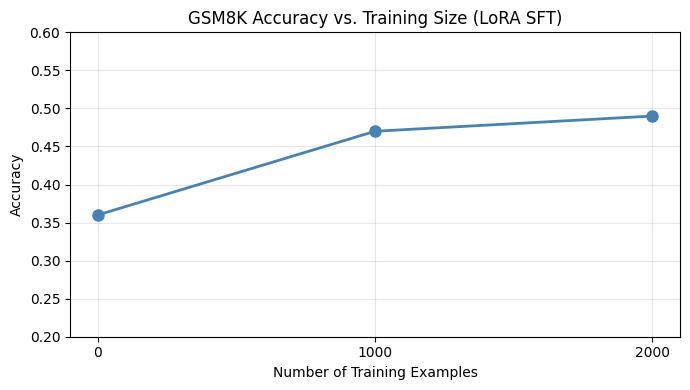

In [ ]:
from pathlib import Path
OUTPUT_DIR = Path("m146_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

import matplotlib.pyplot as plt

training_sizes = [0, 1000, 2000]
accuracies = [0.36, 0.47, 0.49]

plt.figure(figsize=(7, 4))
plt.plot(training_sizes, accuracies, marker='o', linewidth=2, markersize=8, color='steelblue')
plt.xlabel("Number of Training Examples")
plt.ylabel("Accuracy")
plt.title("GSM8K Accuracy vs. Training Size (LoRA SFT)")
plt.xticks(training_sizes)
plt.ylim(0.2, 0.6)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("m146_outputs/accuracy_vs_training.png", dpi=150)
plt.show()

For B.5, train the provided LoRA template on 1,000 GSM8K training examples, then evaluate on the same 100-question test subset.

Write your scaling hypothesis before running 2k. Do you expect a meaningful improvement over 1k? Why?


For B.7, train the provided LoRA template on 2,000 examples and evaluate on the same 100-question test subset.

Make the B.7 accuracy-vs-training-size plot yourself using your results for 0, 1000, and 2000 training examples.


In [ ]:
failures_2k = [r for r in lora_2k_results["records"] if not r["correct"]]
print(f"Total failures: {len(failures_2k)}")

for i, r in enumerate(failures_2k[:2]):
    print(f"\n{'='*60}")
    print(f"FAILURE {i+1}")
    print(f"Question: {r['question']}")
    print(f"\nModel response:\n{r['model_response']}")
    print(f"Extracted: {r['extracted_answer']} | Ground truth: {r['ground_truth']}")

Total failures: 51

FAILURE 1
Question: Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every day with four. She sells the remainder at the farmers' market daily for $2 per fresh duck egg. How much in dollars does she make every day at the farmers' market?

Model response:
She gets 16*3=<<16*3=48>>48 eggs from selling the eggs.
She has 48-12=<<48-12=36>>36 eggs left after eating them and baking muffins for her friends.
So she makes 36*2=$<<36*2=72>>>72 at the farmers’ market everyday.

\boxed{72}
Extracted: 72 | Ground truth: 18

FAILURE 2
Question: Josh decides to try flipping a house.  He buys a house for $80,000 and then puts in $50,000 in repairs.  This increased the value of the house by 150%.  How much profit did he make?

Model response:
He spent 80,000+50,000=$130,000
It went up 150% so that's .8*.15=<<.8*0.15=0.<<=$12,000
So it was worth 80,000+12,000=$92,000
So his profit was 92,000-130,000=-<<92,000-130,000=-38,

### B.10-B.11 Few-Shot Prompting


In [ ]:

def few_shot_messages_from_train(train_split, indices=(0, 1, 2)):
    messages = []
    for idx in indices:
        ex = train_split[int(idx)]
        reasoning = ex["answer"].split("####")[0].strip()
        final = extract_gt(ex["answer"])
        messages.append({"role": "user", "content": ex["question"]})
        messages.append({"role": "assistant", "content": f"{reasoning}\n\n\\boxed{{{final}}}"})
    return messages

In [ ]:
few_shot_messages = few_shot_messages_from_train(gsm8k["train"], indices=(0, 1, 2))
print("Few-shot messages ready!")

Few-shot messages ready!


In [ ]:
# Few-shot base model eval
clear_memory("math_model", "math_tokenizer")
math_model, math_tokenizer = load_math_model()

base_zeroshot_results = evaluate_gsm8k(
    math_model, math_tokenizer,
    gsm8k_test_100,
    num_samples=100,
    batch_size=16,
    output_name="base_zeroshot.json"
)
print(f"Base zero-shot: {base_zeroshot_results['accuracy']:.3f}")

base_fewshot_results = evaluate_gsm8k(
    math_model, math_tokenizer,
    gsm8k_test_100,
    num_samples=100,
    batch_size=16,
    few_shot_messages=few_shot_messages,
    output_name="base_fewshot.json"
)
print(f"Base few-shot: {base_fewshot_results['accuracy']:.3f}")

# Few-shot 2k LoRA eval
clear_memory("math_model", "math_tokenizer")
math_model, math_tokenizer = load_math_model(lora_path="m146_outputs/lora_2k_v2/final_adapter")

lora_zeroshot_results = evaluate_gsm8k(
    math_model, math_tokenizer,
    gsm8k_test_100,
    num_samples=100,
    batch_size=16,
    output_name="lora_zeroshot.json"
)
print(f"LoRA 2k zero-shot: {lora_zeroshot_results['accuracy']:.3f}")

lora_fewshot_results = evaluate_gsm8k(
    math_model, math_tokenizer,
    gsm8k_test_100,
    num_samples=100,
    batch_size=16,
    few_shot_messages=few_shot_messages,
    output_name="lora_fewshot.json"
)
print(f"LoRA 2k few-shot: {lora_fewshot_results['accuracy']:.3f}")

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Base zero-shot: 0.380
Base few-shot: 0.330


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

LoRA 2k zero-shot: 0.490
LoRA 2k few-shot: 0.480


For B.10, build one fixed set of 3 GSM8K training examples and use it for both the base model and the 2k LoRA model. Then compare zero-shot and 3-shot accuracy.

### Bonus: Prompt Playground

For the bonus, start from the original prompt, then write your own prompt variants. You do not need to stop at three trials if you want to keep experimenting.


In [ ]:
def evaluate_one_prompt(model, tokenizer, prompt, name="prompt", n=50):
    result = evaluate_gsm8k(
        model,
        tokenizer,
        gsm8k["test"].select(range(n)),
        num_samples=n,
        system_prompt=prompt,
        batch_size=16,
    )
    return {"prompt_name": name, "accuracy": result["accuracy"], "correct": result["correct"], "total": result["total"]}, result

In [ ]:
PROMPT_0 = SYSTEM_PROMPT  # original

PROMPT_1 = """
You are a precise math tutor. Solve the problem step by step.
- Write out each step clearly
- Show all arithmetic explicitly
- Double-check your calculations before giving the final answer

Final answer rule:
The last line of your response must be exactly:
\\boxed{ANSWER}
""".strip()

PROMPT_2 = """
You are an expert mathematician. Read the problem carefully, identify all given values, and solve step by step.
Before writing your final answer, verify it by checking if it satisfies all conditions in the problem.

Final answer rule:
The last line of your response must be exactly:
\\boxed{ANSWER}
""".strip()

PROMPT_3 = """
You are a careful math solver. Follow these steps:
1. List all the given information
2. Identify what you need to find
3. Solve step by step showing all calculations
4. Verify your answer makes sense

Final answer rule:
The last line of your response must be exactly:
\\boxed{ANSWER}
""".strip()

if "math_model" not in globals() or "math_tokenizer" not in globals():
    math_model, math_tokenizer = load_math_model()

baseline_row, baseline_result = evaluate_one_prompt(math_model, math_tokenizer, PROMPT_0, name="original")
row1, result1 = evaluate_one_prompt(math_model, math_tokenizer, PROMPT_1, name="step_checker")
row2, result2 = evaluate_one_prompt(math_model, math_tokenizer, PROMPT_2, name="verify")
row3, result3 = evaluate_one_prompt(math_model, math_tokenizer, PROMPT_3, name="structured")

print("\n=== BONUS RESULTS ===")
for row in [baseline_row, row1, row2, row3]:
    print(f"{row['prompt_name']}: {row['accuracy']:.3f} ({row['correct']}/{row['total']})")


=== BONUS RESULTS ===
original: 0.440 (22/50)
step_checker: 0.520 (26/50)
verify: 0.420 (21/50)
structured: 0.380 (19/50)


In [ ]:
PROMPT_4 = """
You are a math competition coach. Before solving, carefully re-read the problem and identify:
- All numerical values given
- What the question is actually asking for
- Any tricky conditions or constraints

Then solve step by step with explicit arithmetic. If your answer seems unreasonable, start over.

Final answer rule:
The last line of your response must be exactly:
\\boxed{ANSWER}
""".strip()

PROMPT_5 = """
Solve this math problem. Write your solution in this exact format:
GIVEN: [list all numbers and facts from the problem]
FIND: [what the question asks for]
SOLUTION: [step by step work]
CHECK: [verify the answer makes sense]

Final answer rule:
The last line of your response must be exactly:
\\boxed{ANSWER}
""".strip()

row4, result4 = evaluate_one_prompt(math_model, math_tokenizer, PROMPT_4, name="reread")
row5, result5 = evaluate_one_prompt(math_model, math_tokenizer, PROMPT_5, name="structured_format")

print("\n=== ALL BONUS RESULTS ===")
for row in [baseline_row, row1, row2, row3, row4, row5]:
    print(f"{row['prompt_name']}: {row['accuracy']:.3f} ({row['correct']}/{row['total']})")



=== ALL BONUS RESULTS ===
original: 0.440 (22/50)
step_checker: 0.520 (26/50)
verify: 0.420 (21/50)
structured: 0.380 (19/50)
reread: 0.600 (30/50)
structured_format: 0.380 (19/50)


In [ ]:
PROMPT_BEST = """
You are a precise math competition coach. Before solving, carefully re-read the problem and identify:
- All numerical values given
- What the question is actually asking for
- Any tricky conditions or constraints

Then solve step by step with explicit arithmetic:
1. List all given information
2. Identify what you need to find
3. Solve step by step showing all calculations
4. Check if your answer makes sense

Final answer rule:
The last line of your response must be exactly:
\\boxed{ANSWER}
""".strip()

row_best, result_best = evaluate_one_prompt(math_model, math_tokenizer, PROMPT_BEST, name="combined_best")
print(f"Combined best: {result_best['accuracy']:.3f} ({result_best['correct']}/50)")

Combined best: 0.540 (27/50)


In [ ]:
!pip install weasyprint
!apt-get install -y libpango-1.0-0 libpangoft2-1.0-0 libffi-dev libjpeg-dev libopenjp2-7

In [ ]:
#this is to convert notebook to pdf
from google.colab import drive
drive.mount('/content/drive')

import subprocess
from google.colab import files
import weasyprint

notebook_name = "/content/drive/MyDrive/Colab Notebooks/M146_project_hints.ipynb"

subprocess.run(["jupyter", "nbconvert", "--to", "html", notebook_name])

html_name = notebook_name.replace(".ipynb", ".html")
pdf_name = notebook_name.replace(".ipynb", ".pdf")
weasyprint.HTML(filename=html_name).write_pdf(pdf_name)

files.download(pdf_name)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Colab Notebooks/M146_project_hints.html'